# ICT-32 — Stratification causale du Jeu de la Vie : l'apportionment de Hoel sur substrat certifié

> **Série** : ICT (Information – Causalité – Topologie), phase narrative de l'issue #5726 — « faire du Jeu de la Vie un *vrai* substrat de stratification ICT ». Prérequis : [ICT-Life-SubstratCertifie.ipynb](ICT-Life-SubstratCertifie.ipynb) (phase-zero, calibration des patterns canoniques) et [ICT-6-SortingToTPM-CausalEmergence.ipynb](ICT-6-SortingToTPM-CausalEmergence.ipynb) (l'apportionment appliqué au tri).

La phase-zero a livré un substrat **calibré** : le moteur B3/S23 reproduit les périodes et déplacements des cinq patterns canoniques, et le théorème Lean `hashlife_correct` (track `conway_lean`, clos sans `sorry` sur `main`) garantit que ce calcul de trajectoire est correct. Ce notebook pose la question qui reste ouverte : **à quelle échelle le Jeu de la Vie est-il causalement descriptible ?** La batterie de Hoel (*Causal Emergence 2.0*, arXiv:2503.13395) — information effective, effectiveness normalisée, apportionment glouton — répond par la mesure, et la réponse a deux faces :

1. **Par la trajectoire, le substrat est saturé** : un cycle canonique (glider, blinker) a un déterminisme de 1 et une dégénérescence de 0 — aucune description macro ne bat le micro, et le glouton rend ce verdict en une passe.
2. **Par l'ensemble des graines, la règle jette de l'information** : B3/S23 est massivement dégénérante (sur le tore 3×3, 384 des 512 graines partagent leur successeur avec au moins une autre). Là, une macro qui suit la structure causale de la règle — la partition par **destin** — restaure l'effectiveness de 0.33 à 1.00, et le glouton **découvre seul** cette échelle.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))
from ict.life import (
    canonical_pattern,
    embed,
    trajectory,
    trajectory_symbols,
    torus_ensemble_tpm,
    live_count_strata,
    fate_strata,
)
from ict.causal_emergence import (
    causal_profile,
    greedy_apportionment,
    partition_profile,
)

print("numpy", np.__version__, "| matplotlib", plt.matplotlib.__version__)

numpy 2.4.4 | matplotlib 3.10.8


## 1. Par la trajectoire : la saturation causale des cycles canoniques

Reprenons le glider de la phase-zero : sur un tore 16×16, sa trajectoire visite 64 états distincts (16 positions diagonales × 4 phases) avant de boucler. Encodons ce cycle en TPM — chaque état détermine exactement le suivant — et mesurons son profil causal.

Rappel des primitives (Hoel) : le **déterminisme** mesure à quel point chaque état-cause détermine son effet ; la **dégénérescence** mesure la concentration des effets (plusieurs causes vers le même effet) ; l'**effectiveness** normalisée est leur différence, et l'**information effective** `EI = effectiveness × log2(n)`.

In [2]:
def cycle_tpm_from_trajectory(traj):
    """TPM deterministe du cycle visite par une trajectoire fermee."""
    symbols, _ = trajectory_symbols(traj)
    labels = sorted(set(symbols), key=symbols.index)
    idx = {s: i for i, s in enumerate(labels)}
    n = len(labels)
    tpm = np.zeros((n, n))
    # paires consecutives observees ; si la trajectoire boucle deja
    # (derniere observation = premiere), la fermeture est dans les donnees
    pairs = list(zip(symbols, symbols[1:]))
    if symbols[0] != symbols[-1]:
        pairs.append((symbols[-1], symbols[0]))
    for a, b in pairs:
        tpm[idx[a], idx[b]] = 1.0
    return tpm

film_glider = trajectory(embed(canonical_pattern("glider"), 16), 64)
tpm_glider = cycle_tpm_from_trajectory(film_glider)
prof_glider = causal_profile(tpm_glider)
print(f"glider (tore 16x16) : {prof_glider['n']} etats | "
      f"determinisme {prof_glider['determinism']:.3f} | "
      f"degenerescence {prof_glider['degeneracy']:.3f} | "
      f"effectiveness {prof_glider['effectiveness']:.3f} | "
      f"EI {prof_glider['effective_information']:.3f} bits")
print("EI theorique d'un cycle de 64 :", round(np.log2(64), 3), "bits")

glider (tore 16x16) : 64 etats | determinisme 1.000 | degenerescence 0.000 | effectiveness 1.000 | EI 6.000 bits
EI theorique d'un cycle de 64 : 6.0 bits


### Lecture du résultat

Le profil est celui d'une **rotation pure** : déterminisme 1.000, dégénérescence 0.000, `EI = log2(64) = 6` bits exactement — chaque bit de l'état micro sert à distinguer la cause suivante. Le glouton d'apportionment confirme ce diagnostic en une seule passe : il essaie toutes les fusions de paires, n'en trouve aucune qui améliore l'effectiveness, et s'arrête immédiatement.

In [3]:
res_glider = greedy_apportionment(tpm_glider)
print(f"echelles trouvees : {len(res_glider['scales'])} (le micro seul)")
print(f"deltas : {res_glider['deltas']} | EC = {res_glider['emergent_complexity']:.3f}")

echelles trouvees : 1 (le micro seul)
deltas : [] | EC = 0.000


### Lecture du résultat — EC = 0 structurel

**Complexité émergente nulle, et c'est un théorème de situation, pas un échec de l'outil** : sur une TPM de déterminisme 1 et de dégénérescence 0, l'effectiveness vaut déjà 1 — le maximum — et fusionner deux états ne peut que casser le déterminisme (si leurs successeurs divergent) ou concentrer les effets (s'ils convergent). Une particule isolée du Jeu de la Vie **est sa propre description minimale**.

Il existe pourtant une description macro familière du glider : « une particule de phase *p* quelque part ». C'est le quotient par translation — mesurons-le systématiquement avec `partition_profile`, l'outil d'évaluation d'une partition dessinée : les 64 états micro groupés par phase (4 strates).

In [4]:
# le glider boucle en 64 etats = 16 positions x 4 phases ; la strate = la phase
groups_phase = [[i for i in range(64) if i % 4 == p] for p in range(4)]
prof_quotient = partition_profile(tpm_glider, groups_phase)
print(f"micro      : effectiveness {prof_glider['effectiveness']:.3f} | EI {prof_glider['effective_information']:.3f} bits")
print(f"quotient   : effectiveness {prof_quotient['effectiveness']:.3f} | EI {prof_quotient['effective_information']:.3f} bits")
print(f"perte EI   : {prof_glider['effective_information'] - prof_quotient['effective_information']:.3f} bits = log2(16 positions)")

micro      : effectiveness 1.000 | EI 6.000 bits
quotient   : effectiveness 1.000 | EI 2.000 bits
perte EI   : 4.000 bits = log2(16 positions)


### Lecture du résultat

La description « particule » est **causalement étanche** : effectiveness 1.000 conservée, EI réduit d'exactement `log2(16)` bits — précisément l'information de position que la strate jette. Perdre la position ne perd **aucune cause** : la dynamique de phase est autonome. C'est la lecture formelle de l'intuition « un glider est une particule » — et la porte ouverte à la question inverse : existe-t-il des cas où la macro ne se contente pas d'être étanche, mais **bat** le micro ?

## 2. Par l'ensemble des graines : la règle jette de l'information

La trajectoire isolée est saturée ; l'**ensemble des conditions initiales** ne l'est pas. La règle B3/S23 est une fonction des 2^(k²) grilles d'un tore k×k vers leurs successeurs — une fonction *beaucoup non injective* : plusieurs graines différentes évoluent vers la même grille au pas suivant. Cette dégénérescence n'est pas du bruit (la règle est déterministe) : c'est de la **perte d'information structurelle de la règle elle-même**.

Commençons petit : le tore 2×2 et ses 16 graines.

In [5]:
tpm2, succ2 = torus_ensemble_tpm(2)
prof2 = causal_profile(tpm2)
collisions = 16 - len(set(succ2.tolist()))
print(f"tore 2x2 : {prof2['n']} graines | successeurs distincts {len(set(succ2.tolist()))} | collisions {collisions}")
print(f"determinisme {prof2['determinism']:.3f} | degenerescence {prof2['degeneracy']:.3f} | "
      f"effectiveness {prof2['effectiveness']:.3f} | EI {prof2['effective_information']:.3f} bits")

tore 2x2 : 16 graines | successeurs distincts 5 | collisions 11
determinisme 1.000 | degenerescence 0.672 | effectiveness 0.328 | EI 1.311 bits


### Lecture du résultat

**11 collisions sur 16 graines** : la dégénérescence saute à 0.672, l'effectiveness tombe à 0.328. Vu de l'ensemble, l'état micro d'une graine ne détermine pas sa cause en retour — la règle a fondu 16 origines possibles en 5 avenirs. Visualisons la structure de ces fusions : les strates de destin (les fibres de la fonction successeur) et leurs tailles.

tailles des strates de destin : [12, 1, 1, 1, 1]


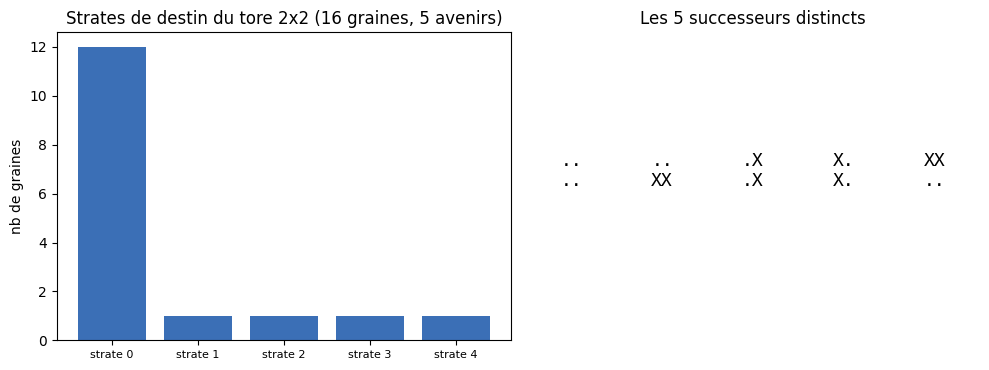

In [6]:
fate2 = fate_strata(succ2)
succ_ids = sorted(set(succ2.tolist()))
print("tailles des strates de destin :", [len(g) for g in fate2])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].bar(range(len(fate2)), [len(g) for g in fate2], color="#3b6fb6")
axes[0].set_xticks(range(len(fate2)))
axes[0].set_xticklabels([f"strate {i}" for i in range(len(fate2))], fontsize=8)
axes[0].set_ylabel("nb de graines")
axes[0].set_title("Strates de destin du tore 2x2 (16 graines, 5 avenirs)")

rendu = []
for s in succ_ids:
    bits = np.array(list(map(int, bin(s)[2:].zfill(4))), dtype=np.uint8).reshape(2, 2)
    rendu.append("\n".join("".join("X" if v else "." for v in row) for row in bits))
axes[1].axis("off")
axes[1].set_title("Les 5 successeurs distincts")
for i, txt in enumerate(rendu):
    axes[1].text(0.10 + 0.20 * i, 0.55, txt, family="monospace", fontsize=13,
                 va="center", ha="center")
plt.tight_layout()
plt.show()

### Lecture du résultat

Les tailles racontent une hiérarchie brutale : **12 graines sur 16 fondent vers le même avenir — la grille vide** — et les quatre strates restantes sont des singletons : les quatre **dominos** (deux cellules adjacentes), chacun son propre successeur. Sur ce tore minuscule, le voisinage emmêlé par le rebouclage (une cellule voisine d'une autre par plusieurs directions à la fois) rend la règle fortement dissipative : seules 4 graines sur 16 se perpétuent à l'identique. La **structure** de la mesure, elle, est générale : la règle comprime l'ensemble des origines.

## 3. La macro que la dynamique suggère — deux partitions dessinées

Hoel (2013) : une macro-échelle gagne quand elle **réduit la dégénérescence sans casser le déterminisme**. Sur notre ensemble dégénérant, testons deux partitions dessinées :

- **la partition par destin** : grouper les graines qui partagent leur successeur — la partition que la dynamique *elle-même* suggère (son squelette causal) ;
- **la partition par population** : grouper par nombre de cellules vivantes — une observable macro naturelle… mais qui ne suit pas la règle.

In [7]:
rows = []
rows.append(("micro (16 etats)", prof2))
rows.append(("destin   (%d strates)" % len(fate2), partition_profile(tpm2, fate2)))
rows.append(("population (%d strates)" % len(live_count_strata(2, succ2)),
             partition_profile(tpm2, live_count_strata(2, succ2))))

print(f"{'partition':<22}{'det':>7}{'deg':>7}{'eff':>7}{'EI (bits)':>10}")
for name, p in rows:
    print(f"{name:<22}{p['determinism']:>7.3f}{p['degeneracy']:>7.3f}"
          f"{p['effectiveness']:>7.3f}{p['effective_information']:>10.3f}")

partition                 det    deg    eff EI (bits)
micro (16 etats)        1.000  0.672  0.328     1.311
destin   (5 strates)    1.000  0.000  1.000     2.322
population (5 strates)  0.921  0.756  0.165     0.383


### Lecture du résultat

Le contraste est net des deux côtés :

- **destin** : effectiveness 0.328 → **1.000**, EI 1.31 → 2.32 bits. Les strates de destin préservent le déterminisme (chaque strate a un successeur unique, donc la ligne macro reste un one-hot) **et** annulent la dégénérescence (les 5 strates ont 5 avenirs distincts). La macro bat le micro de +0.67 d'effectiveness — c'est l'émergence causale de Hoel, mesurée sur le substrat certifié.
- **population** : effectiveness 0.328 → **0.165** — *pire* que le micro. Grouper par population mélange des graines aux avenirs différents : la ligne macro devient floue (déterminisme 0.92 < 1) et les effets se concentrent (dégénérescence 0.756). Une observable macro naturelle n'est **pas** une macro causale.

## 4. Le glouton découvre l'échelle seul

Les strates de destin, nous les avons dessinées — mais le glouton de `greedy_apportionment` n'en sait rien : il fusionne paire par paire en maximisant l'effectiveness à chaque pas. S'il aboutit de lui-même à la partition gagnante, la stratification n'est pas un artefact de notre dessin.

In [8]:
res2 = greedy_apportionment(tpm2)
print(f"chemin : {len(res2['scales'])} echelles, deltas positifs {len(res2['deltas'])}, EC = {res2['emergent_complexity']:.3f}")
print(f"{'taille':>6}{'eff':>9}{'EI':>8}{'delta':>8}  fusion (positions)")
for s in res2["scales"]:
    fusion = f"{s['merged'][0]}+{s['merged'][1]}" if s["merged"] else "-"
    d = s["delta_cp"] if s["delta_cp"] is not None else float("nan")
    print(f"{s['size']:>6}{s['effectiveness']:>9.4f}{s['effective_information']:>8.3f}{d:>8.4f}  {fusion}")
print(f"taille finale {res2['scales'][-1]['size']} = nb de strates de destin ({len(fate2)})")

chemin : 12 echelles, deltas positifs 11, EC = 6.697
taille      eff      EI   delta  fusion (positions)
    16   0.3278   1.311     nan  -
    15   0.3507   1.370  0.0228  0+1
    14   0.3768   1.435  0.0261  0+1
    13   0.4069   1.506  0.0302  0+2
    12   0.4421   1.585  0.0352  0+3
    11   0.4836   1.673  0.0415  0+3
    10   0.5331   1.771  0.0495  0+3
     9   0.5931   1.880  0.0600  0+3
     8   0.6667   2.000  0.0736  0+4
     7   0.7580   2.128  0.0914  0+5
     6   0.8710   2.252  0.1130  0+5
     5   1.0000   2.322  0.1290  0+5
taille finale 5 = nb de strates de destin (5)


### Lecture du résultat

**Le glouton re-dérive la partition par destin** : chemin monotone 16 → 5 états, effectiveness 0.328 → 1.000 en onze fusions, échelle terminale de 5 états — exactement le nombre d'avenirs distincts. La colonne des fusions montre la mécanique : la grande strate grandit par **absorption successive** des singletons. L'EC de 6.70 dit de plus que le travail causal est **distribué** le long de l'échelle (onze fusions d'ampleur croissante, de 0.023 à 0.129, plutôt qu'un saut unique) : la stratification n'a pas un « palier magique », elle se construit.

## 5. La structure tient à plus grande échelle — tore 3×3

Le tore 2×2 est un monde dégénéré ; la question est de savoir si la structure de la mesure (dégénérescence micro massive, restauration par le destin) survit avec un espace d'états 32× plus riche. Le tore 3×3 porte 512 graines — toujours tractable pour un profil et une partition dessinée (le glouton, lui, coûte O(n⁴) : documenté, non exécuté).

In [9]:
tpm3, succ3 = torus_ensemble_tpm(3)
prof3 = causal_profile(tpm3)
fate3 = fate_strata(succ3)
macro3 = partition_profile(tpm3, fate3)
coll3 = 512 - len(set(succ3.tolist()))
print(f"tore 3x3 : {prof3['n']} graines | collisions {coll3} | degenerescence {prof3['degeneracy']:.3f}")
print(f"micro    : effectiveness {prof3['effectiveness']:.4f} | EI {prof3['effective_information']:.3f} bits")
print(f"destin   : effectiveness {macro3['effectiveness']:.4f} | EI {macro3['effective_information']:.3f} bits ({len(fate3)} strates)")

tore 3x3 : 512 graines | collisions 384 | degenerescence 0.656
micro    : effectiveness 0.3435 | EI 3.092 bits
destin   : effectiveness 0.9978 | EI 6.984 bits (128 strates)


### Lecture du résultat

La structure tient, et s'aggrave dans le bon sens : **384 collisions sur 512 graines** (75 %), dégénérescence micro 0.656, et la partition par destin la restaure presque parfaitement — effectiveness 0.998, EI 3.09 → 6.98 bits. Plus l'espace d'états est riche, plus la règle B3/S23 y fond les origines — et plus le squelette causal (les 128 avenirs distincts) concentre la description.

## 6. Synthèse — un substrat de stratification *par l'ensemble*

| Régime | Mesure | Verdict |
|---|---|---|
| Trajectoire isolée (glider 64 états) | det 1.000, deg 0.000 | **saturé** — EC = 0, le micro est sa propre description minimale |
| Quotient translation (4 phases) | eff 1.000 conservée | **étanche** — la description particule ne perd aucune cause |
| Ensemble des graines (2×2, 16) | deg 0.672, eff 0.328 | **dégénérant** — la règle jette l'information |
| Partition destin (2×2 / 3×3) | eff 1.000 / 0.998 | **la macro bat le micro** (+0.67 / +0.65) |
| Partition population (2×2) | eff 0.165 | témoin négatif — une observable ≠ une macro causale |

Le contraste avec le tri ([ICT-6](ICT-6-SortingToTPM-CausalEmergence.ipynb)) éclaire la complémentarité des substrats : le tri stratifie **par la trajectoire** (convergence de multiples permutations vers peu d'états triés), le Jeu de la Vie stratifie **par l'ensemble** (la règle elle-même fond les origines). Les deux portent la thèse de Hoel par des voies distinctes — c'est ce qui en fait des bancs complémentaires dans la batterie ICT.

Le pont Lean reste le garant du socle : `hashlife_correct` (clos, sans `sorry`) certifie que le calcul des trajectoires mesuré ici calcule bien la dynamique naïve qu'il prétend calculer — la calibration de la phase-zero et la stratification de ce notebook héritent de cette garantie. Issue #5726, Epic #4588.

## Exercice 1 — les points fixes du tore 2×2

Une graine est un **point fixe** si elle est son propre successeur. Le cas paraît trivial — et cache un piège : la grille vide est évidemment un point fixe, mais elle dort **dans la grande strate de destin** (12 graines mènent à elle), tandis que les strates de taille 1 sont, elles, seules face à leur destin.

**Étapes indicatives** : (1) lister les `s` de `range(16)` tels que `succ2[s] == s` ; (2) combien y en a-t-il, et lesquels sont des dominos ? (3) expliquer pourquoi « point fixe » n'implique PAS « strate de taille 1 » — une strate groupe les graines par destin, et le vide est le destin partagé de 12 graines, dont la graine vide elle-même.

In [10]:
def points_fixes_tore2():
    """Renvoie la liste des graines s du tore 2x2 telles que succ2[s] == s."""
    # Etape 1 : iterer sur range(16)
    # Etape 2 : garder s si succ2[s] == s
    # Etape 3 : verifier que chaque point fixe forme une strate de destin seule
    pass  # TODO etudiant
    return None  # TODO etudiant

print("Exercice a completer")

Exercice a completer


## Exercice 2 — le témoin négatif tient-il sur le tore 3×3 ?

Sur le 2×2, la partition par population perd face au micro (0.165 < 0.328). Le 3×3 a 10 strates de population (0 à 9 cellules) au lieu de 5 — plus de résolution, donc peut-être moins de flou.

**Étapes indicatives** : (1) construire `live_count_strata(3, succ3)` ; (2) évaluer avec `partition_profile(tpm3, ...)` ; (3) comparer à l'effectiveness micro 0.3435 — le verdict « pire que le micro » survit-il à 512 états ?

In [11]:
def effectiveness_population_tore3():
    """Renvoie l'effectiveness de la partition par population sur le tore 3x3."""
    # Etape 1 : strates = live_count_strata(3, succ3)
    # Etape 2 : profil = partition_profile(tpm3, strates)
    # Etape 3 : renvoyer profil['effectiveness'] et comparer a 0.3435
    pass  # TODO etudiant
    return None  # TODO etudiant

print("Exercice a completer")

Exercice a completer


## Exercice 3 — l'EC du chemin : distribué ou concentré ?

L'EC du chemin glouton du 2×2 vaut 6.70 sur onze fusions. Que mesure exactement cette répartition ? Construisez un contre-exemple : une liste de deltas **concentrés** (une fusion porte tout) et une liste **distribuée** (même nombre de fusions, contributions égales), et comparez leurs `emergent_complexity`.

**Étapes indicatives** : (1) appeler `emergent_complexity([10.0] + [0.1] * 10)` (concentré) et `emergent_complexity([1.0] * 11)` (distribué) ; (2) expliquer pourquoi, à gain total égal, le chemin distribué a la plus grande EC ; (3) relier au chemin mesuré du 2×2 — ses deltas s'étalent de ~0.02 à ~0.13 : plutôt concentrés ou distribués ?

In [12]:
def compare_ec_concentre_distribue():
    """Renvoie (ec_concentre, ec_distribue) pour les deux listes de l'enonce."""
    # Etape 1 : importer emergent_complexity depuis ict.causal_emergence
    # Etape 2 : mesurer les deux cas
    # Etape 3 : interpreter face aux deltas du chemin 16 -> 5 du tore 2x2
    pass  # TODO etudiant
    return None  # TODO etudiant

print("Exercice a completer")

Exercice a completer


## Conclusion

Le Jeu de la Vie entre dans la batterie ICT comme **substrat de stratification par l'ensemble** : ses trajectoires certifiées sont causalement saturées (la particule est sa propre description minimale, et son quotient par translation est étanche), mais sa règle fond massivement les origines — et la macro qui suit ce squelette causal (les strates de destin) bat le micro de deux tiers d'effectiveness, découverte *ex nihilo* par le glouton. Suite possible : l'extension de l'analyse de bassin aux tores 3×3 (quels attractors terminaux ? quels bassins ?), et le lien avec les mesures d'agence post-ablation d'[ICT-31](ICT-31-ContrasteTroisSubstrats.ipynb).